In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
n_samples = 100



Matplotlib is building the font cache; this may take a moment.


In [3]:
X = torch.randn(n_samples, 1) * 2
print(X.shape)

torch.Size([100, 1])


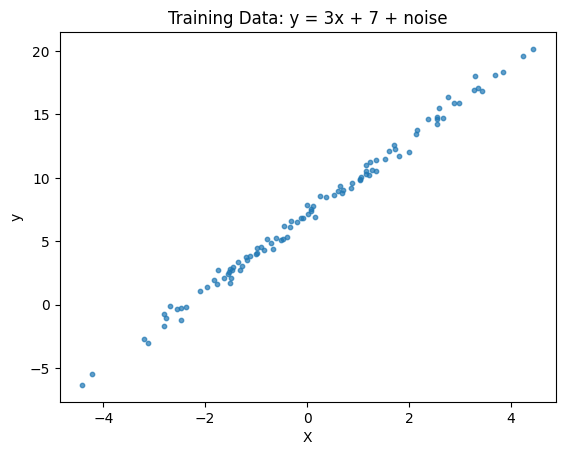

In [6]:
noise = torch.randn(n_samples, 1) * 0.5
y_true = 3 * X + 7 + noise

plt.scatter(X.numpy(), y_true.numpy(), s = 10, alpha = 0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Training Data: y = 3x + 7 + noise")
plt.show()


In [7]:
model = nn.Linear(1, 1)
print(f"Initial weight: {model.weight.item()}")
print(f"Initial bias: {model.bias.item()}")


loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Initial weight: -0.6715279817581177
Initial bias: 0.24239420890808105


In [8]:
model.parameters()

<generator object Module.parameters at 0x124357760>

In [9]:
for name, param in model.named_parameters():
    print(f"{name}: value={param.data}, shape={param.shape}")

weight: value=tensor([[-0.6715]]), shape=torch.Size([1, 1])
bias: value=tensor([0.2424]), shape=torch.Size([1])


In [13]:
n_epochs = 200
losses = []

for epoch in range(n_epochs):
    y_pred = model(X)
    loss = loss_fn(y_true, y_pred)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{(epoch+1)}/{n_epochs}], Loss: {loss.item()}")

print(f"\n学到的 weight: {model.weight.item():.4f} (真实值: 3.0)")
print(f"学到的 bias: {model.bias.item():.4f} (真实值: 7.0)")    

Epoch [20/200], Loss: 0.33246445655822754
Epoch [40/200], Loss: 0.24086277186870575
Epoch [60/200], Loss: 0.19986982643604279
Epoch [80/200], Loss: 0.18152497708797455
Epoch [100/200], Loss: 0.17331533133983612
Epoch [120/200], Loss: 0.16964153945446014
Epoch [140/200], Loss: 0.16799749433994293
Epoch [160/200], Loss: 0.1672617346048355
Epoch [180/200], Loss: 0.1669323742389679
Epoch [200/200], Loss: 0.16678503155708313

学到的 weight: 2.9936 (真实值: 3.0)
学到的 bias: 7.0630 (真实值: 7.0)
